In [1]:
import astropy.units as u
import astropy.constants as c
from astropy.io import fits
from astropy.visualization import quantity_support

import matplotlib.pyplot as plt
import numpy as np
import os

quantity_support()
%matplotlib widget

In [2]:
# 12CO
# CO12_10 = 115.27 * u.GHz
CO12_76 = 806.651806 * u.GHz
CO12_87 = 921.7997 * u.GHz
CO12_98 = 1036.912393 * u.GHz
CO12_109 = 1151.985452 * u.GHz

CO12 = [CO12_76, CO12_87, CO12_98, CO12_109]

# 13CO
# CO13_10 = 110.20 * u.GHz
CO13_76 = 771.184125 * u.GHz
CO13_87 = 881.272808 * u.GHz
CO13_98 = 991.329305 * u.GHz
CO13_109 = 1101.3495971 * u.GHz

CO13 = [CO13_76, CO13_87, CO13_98, CO13_109]

# water
H2O_lines = [
    
]

# """other"""
CII = (c.c / (157.7 * u.um)).to(u.GHz)
OI = (c.c / (63 * u.um)).to(u.GHz)
OIII = (c.c / (88 * u.um)).to(u.GHz)


lines = (
    CO12 +
    CO13 +
    [CII, OI, OIII]
)
names = (
    ['$^{12}$' + 'CO' + '$_{' + f'{ju}-{jl}' + '}$' for jl, ju in zip(range(6, 10), range(7, 11))] +
    ['$^{13}$' + 'CO' + '$_{' + f'{ju}-{jl}' + '}$' for jl, ju in zip(range(6, 10), range(7, 11))] +
    ['[CII]', '[OI]', '[OIII]']
)

In [3]:
z_nu = lambda nu, nu_rest: ((nu_rest - nu) / nu).decompose()
fobs = lambda nu_rest, z: nu_rest / (1 + z)

Text(0, 0.5, 'Redshift')

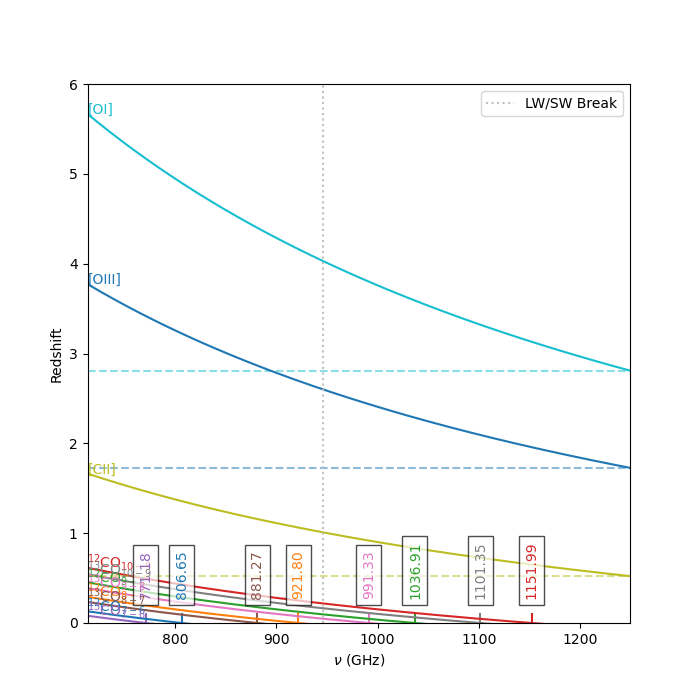

In [4]:
nus = (c.c / (np.arange(420, 240 - .1, -.1) * u.um)).to(u.GHz)

fig, ax = plt.subplots(figsize=(7, 7))
for i, line in enumerate(lines):
    zs = z_nu(nus, line)
    l, = ax.plot(nus, zs)

    # Incidate where multiple lines are visible at once
    ax.axhline(zs[-1], color=l.get_color(), linestyle='--', alpha=0.5)

    # Indicate where lines appear at z = 0
    ax.scatter(line, 0, s=200, marker='|', color=l.get_color())
    ax.text(
        line,
        6 * .05,
        f'{line.value:.2f}',
        bbox=dict(facecolor='w', alpha=0.7),
        rotation=90,
        ha='center',
        color=l.get_color()
    )
    ax.text(nus[0], zs[0], names[i], color=l.get_color())

ax.axvline((c.c / (317 * u.um)), color='silver', linestyle=':', label='LW/SW Break')
ax.legend(loc='upper right')
ax.set_xlim(nus[0], nus[-1])
ax.set_ylim(0, 6)

ax.set_xlabel('$\\nu$ (GHz)')
ax.set_ylabel('Redshift')

/tmp/ipykernel_45576/1530843120.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integ = np.trapz(y * u.V, x * u.GHz)
/tmp/ipykernel_45576/1530843120.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integ_new = np.trapz(y_new, x_new * u.GHz)


(<Quantity 364949.12183055 GHz V>,
 <Quantity 364754.83365646 GHz V>,
 np.float64(-0.0005323705756899817))

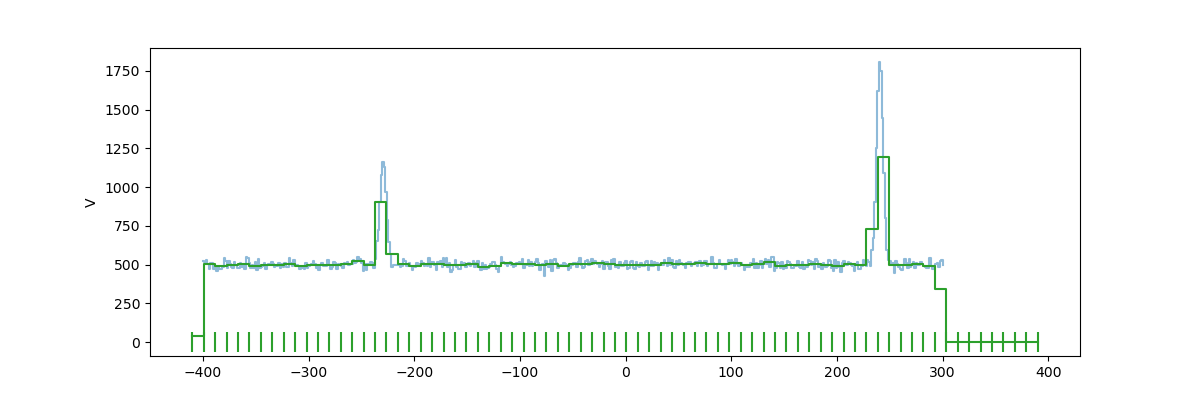

In [5]:
def rebin(x, y, x_new):
    '''
    Assign values from the old array to the new, weighted by their overlap with
    the new bins.
    '''
    y_new = np.zeros_like(x_new).value * y.unit
    for i, (l_new, r_new) in enumerate(zip(x_new[:-1], x_new[1:])):
        for j, (l, r) in enumerate(zip(x[:-1], x[1:])):
            rightest_left = max(l_new, l)
            leftest_right = min(r_new, r)
            overlap_distance = leftest_right - rightest_left
            if overlap_distance <= 0:
                continue
            dx_new = r_new - l_new
            weight = overlap_distance / dx_new
            y_new[i] += (y[j] * weight)
    if len(y_new) > 1:
        y_new[-1] = y_new[-2]
    return x_new, y_new


# test:
# initial bin edges
x = np.linspace(-400, 300, num=500)
y = np.random.normal(size=len(x)) * 20 + 500
sig = 3.
x0 = 240.
a = 10000
pk = a * (1. / sig / np.sqrt(2 * np.pi) * np.exp(-.5 * (x - x0)**2 / sig**2))
y += pk
x0 = -230
a = 5000
pk = a * (1. / sig / np.sqrt(2 * np.pi) * np.exp(-.5 * (x - x0)**2 / sig**2))
y += pk

# new bin edges
x_new = np.linspace(-410, 390, num=75)
_, y_new = rebin(x * u.GHz, y * u.V, x_new * u.GHz)

fig, ax = plt.subplots(figsize=(12,4))

ax.step(x, y, where='post', zorder=0, alpha=0.5)
ax.scatter(x_new, np.zeros_like(x_new), s=200, marker='|', color='C2')
ax.step(x_new, y_new, color='C2', where='post')

integ = np.trapz(y * u.V, x * u.GHz)
integ_new = np.trapz(y_new, x_new * u.GHz)

integ, integ_new, ((integ_new - integ) / integ).value

1.5158941222080318e-07 W s(1/2) / (sr m2) 1.4978357741515071e-07 W s(1/2) / (sr m2)
3.839229827226562e-07 W s(1/2) / (sr m2) 3.8433570749038465e-07 W s(1/2) / (sr m2)


/tmp/ipykernel_45576/3716176013.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(nei_model_lw, nus_model_lw).to(u.W * u.s**.5 / u.m**2 / u.sr),
/tmp/ipykernel_45576/3716176013.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(nei_lw, nus_lw).to(u.W * u.s**.5 / u.m**2 / u.sr)
/tmp/ipykernel_45576/3716176013.py:72: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(nei_model_sw, nus_model_sw).to(u.W * u.s**.5 / u.m**2 / u.sr),
/tmp/ipykernel_45576/3716176013.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(nei_sw, nus_sw).to(u.W * u.s**.5 / u.m**2 / u.sr)


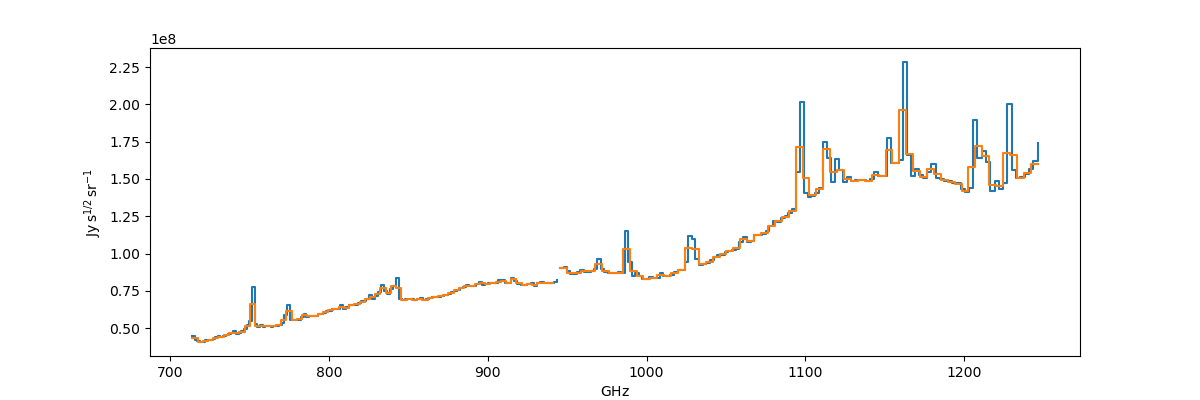

In [6]:
def TIM_NEI_model(which='SW', path='/home/evanmayer/github/tim-inst_modl/Spectral_loading_model/'):
    '''
    TIM fiducial spectral loading model. Load NEIs for each channel from
    Jianyang (Frank) Fu's model:
    https://github.com/tim-balloon/tim-inst_modl/blob/master/Spectral_loading_model/Spectral_loading.ipynb,
    Output is NEI, so needs to be divided by sqrt(t_int) to yield Jy/sr.

    Parameters
    ----------
    which : str (optional)
        Specify whether to load the short-wave (SW) or long-wave (LW) module's
        noise.
    path : str (optional)
        Specify the directory containing the NEI model output data.

    Returns
    -------
    freq_module : astropy.Quantity
        Frequency axis, as read from the NEI model file, in Hz
    nei : astropy.quantity
        NEI numbers for each frequency, in Jy s^(1/2) / sr
    '''
    fname = os.path.join(path, f'TIM_{which}_loading.tsv')
    lambda_micron, nep, nei = np.genfromtxt(
        fname,
        skip_header=0,
        dtype=float,
        delimiter='\t',
        unpack=True
    )
    # add units and flip order: cube spectral axis ordered by increasing frequency
    lambda_micron *= u.micron
    nep = nep[::-1] * u.W / (u.Hz ** 0.5)
    nei = nei[::-1] * (u.Jy / u.sr) * (u.s ** 0.5)
    freq_module = (c.c / lambda_micron[::-1]).to(u.Hz)
    return freq_module, nei


def beam_solid_angle(D, nus):
    lambds = (c.c / nus).to(u.um)
    thetas = (1.2 * lambds / D).decompose() * u.rad
    omegas = ((np.pi / 4 / np.log(2)) * thetas ** 2).to(u.sr)
    return omegas


nus_model_lw, nei_model_lw = TIM_NEI_model(which='LW')
nus_model_sw, nei_model_sw = TIM_NEI_model(which='SW')
nus_model_sw = nus_model_sw.to(u.GHz)
nus_model_lw = nus_model_lw.to(u.GHz)

dnu_sw = (nus_model_sw / 250).to(u.GHz)
dnu_lw = (nus_model_lw / 250).to(u.GHz)

nus_sw = np.arange(nus_model_sw[0].value, nus_model_sw[-1].value, dnu_sw.mean().value) * u.GHz
nus_lw = np.arange(nus_model_lw[0].value, nus_model_lw[-1].value, dnu_lw.mean().value) * u.GHz

fig, ax = plt.subplots(figsize=(12,4))
ax.step(nus_model_sw, nei_model_sw, color='C0', where='post')
ax.step(nus_model_lw, nei_model_lw, color='C0', where='post')

_, nei_sw = rebin(nus_model_sw, nei_model_sw, nus_sw)
_, nei_lw = rebin(nus_model_lw, nei_model_lw, nus_lw)
ax.step(nus_sw, nei_sw, color='C1', where='post')
ax.step(nus_lw, nei_lw, color='C1', where='post')

# Sanity check:
print(
    np.trapz(nei_model_lw, nus_model_lw).to(u.W * u.s**.5 / u.m**2 / u.sr), 
    np.trapz(nei_lw, nus_lw).to(u.W * u.s**.5 / u.m**2 / u.sr)
)
print(
    np.trapz(nei_model_sw, nus_model_sw).to(u.W * u.s**.5 / u.m**2 / u.sr), 
    np.trapz(nei_sw, nus_sw).to(u.W * u.s**.5 / u.m**2 / u.sr)
)

In [7]:
dnu_sw

<Quantity [3.78287013, 3.79123359, 3.79961553, 3.80801601, 3.81643506,
           3.82487272, 3.83332904, 3.84180406, 3.85029781, 3.85881034,
           3.86734168, 3.87589191, 3.88446102, 3.89304908, 3.90165613,
           3.9102822 , 3.91892735, 3.92759161, 3.93627503, 3.94497764,
           3.9536995 , 3.96244063, 3.9712011 , 3.97998094, 3.98878018,
           3.99759887, 4.00643707, 4.0152948 , 4.02417212, 4.03306907,
           4.04198568, 4.05092201, 4.05987809, 4.06885398, 4.0778497 ,
           4.08686533, 4.09590088, 4.10495641, 4.11403195, 4.12312757,
           4.13224329, 4.14137916, 4.15053524, 4.15971155, 4.16890816,
           4.1781251 , 4.18736242, 4.19662016, 4.20589835, 4.21519707,
           4.22451636, 4.23385624, 4.24321676, 4.25259799, 4.26199996,
           4.2714227 , 4.28086629, 4.29033075, 4.29981614, 4.3093225 ,
           4.31884988, 4.32839831, 4.33796787, 4.34755858, 4.35717049,
           4.36680365, 4.37645811, 4.38613391, 4.39583112, 4.40554976,
      

In [23]:
# l = np.linspace(240, 420, num=63 * 2) * u.um
# dnu = c.c / l[:-1] - c.c / l[1:]
# R = ((c.c / l[:-1]) / dnu.to(u.GHz)).decompose()

# fig, ax = plt.subplots()
# ax.plot((c.c / l[:-1]).to(u.GHz), R)
# ax.axhline(250)
# ax.axhline(R.mean(), linestyle='--')

Vy CMa spectrum

Herschel Science Archive # 1342231976

In [9]:
fname = '/home/evanmayer/github/tim-memos/mission_planning/SPIRE-S-cal_targets_anonymous1757998937/SPIRE-S-cal_targets/1342231976_spectrometerCalibrator_pointOffCorr.fits.gz'
hdu = fits.open(fname)
d_lw = hdu[2].data
freq_lw = d_lw['wave'] * u.GHz
flux_lw = d_lw['flux'] * u.Jy

d_sw = hdu[3].data
freq_sw = d_sw['wave'] * u.GHz
flux_sw = d_sw['flux'] * u.Jy

_, flux_lw_meas = rebin(freq_lw, flux_lw, nus_lw)
_, flux_sw_meas = rebin(freq_sw, flux_sw, nus_sw)

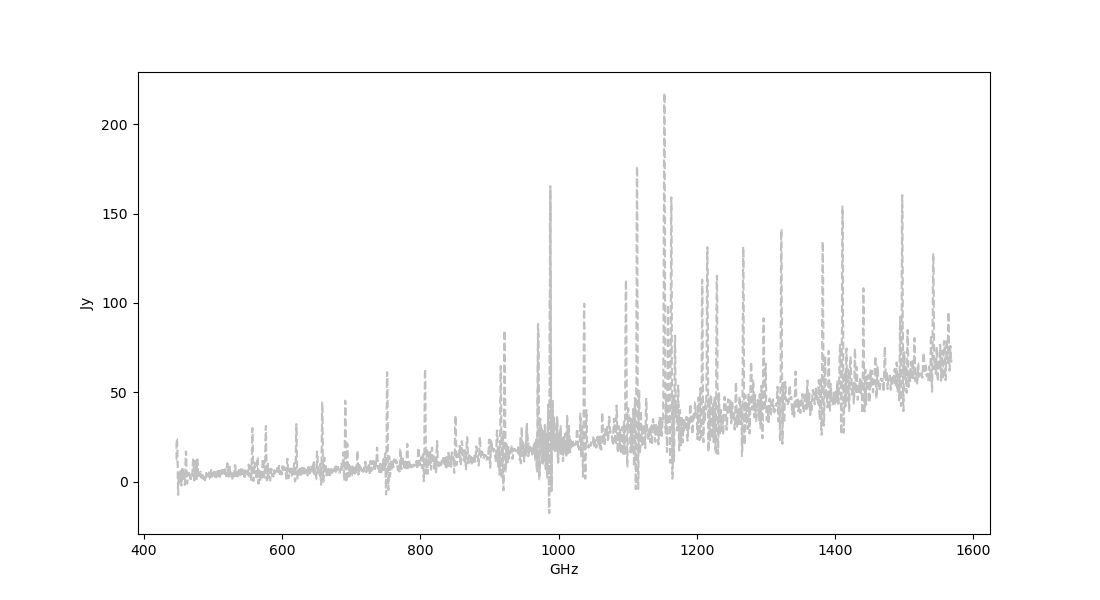

In [10]:
fig, ax = plt.subplots(figsize=(11,6), sharex=True)
# loaded Herschel spectrum
ax.step(freq_lw, flux_lw, color='silver', linestyle='--', where='post')
ax.step(freq_sw, flux_sw, color='silver', linestyle='--', where='post')

In [11]:
np.diff(freq_sw).mean()

<Quantity 0.29979246 GHz>

In [ ]:
# TIM beam size, sr
omegas_sw_tim = beam_solid_angle(2 * u.m, nus_sw)
omegas_lw_tim = beam_solid_angle(2 * u.m, nus_lw)
# Herschel beam size, sr
# https://www.cosmos.esa.int/documents/12133/1035800/The+Herschel+Explanatory+Supplement%2C%20Volume+IV+-+THE+SPECTRAL+AND+PHOTOMETRIC+IMAGING+RECEIVER+%28SPIRE%29/c36d074d-32b4-48ec-b13f-4ca320788df3
omegas_sw_spire = beam_solid_angle(3.287 * u.m, nus_sw)
omegas_lw_spire = beam_solid_angle(3.287 * u.m, nus_lw)

# double check against f2f slides, those say ~3 Jy s^1/2
print((np.nanmean(nei_lw * omegas_lw_tim), np.nanmean(nei_sw * omegas_sw_tim)))

# sanity check: how many K?
print((np.nanmean(nei_lw * omegas_lw_tim) / (2 * c.k_B / (0.5 * np.pi * u.m**2))).to(u.K * u.s**.5))

(<Quantity 3.48780856 Jy s(1/2)>, <Quantity 3.83451364 Jy s(1/2)>)
0.001984080266944657 K s(1/2)


In [13]:
(1 * u.rad * (350 * u.um) / (2 * u.m)).to(u.arcsec) / 2

<Quantity 18.04817055 arcsec>

In [14]:
beam_solid_angle(2 * u.m, ((c.c)/(350*u.um)).to(u.GHz))

<Quantity 4.99692706e-08 sr>

In [15]:
omegas_lw_tim.mean()

<Quantity 5.46091881e-08 sr>

Text(0.5, 0.98, '0.1 s')

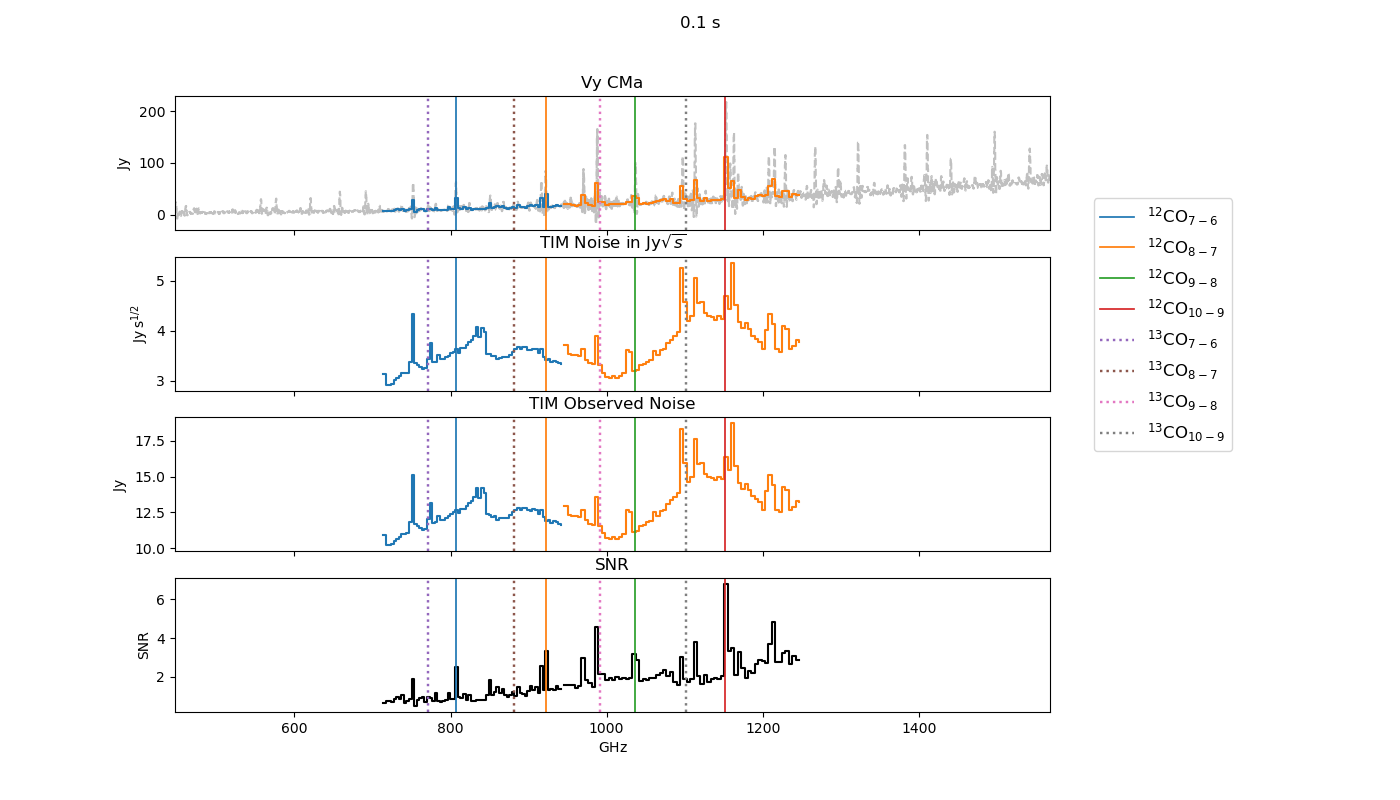

In [16]:
# integrate down the noise
t_obs = 40 * (1/488) * u.s

fig, ax = plt.subplots(figsize=(14,8), nrows=4, sharex=True)

# loaded Herschel spectrum
ax[0].step(freq_lw, flux_lw, color='silver', linestyle='--', where='post')
ax[0].step(freq_sw, flux_sw, color='silver', linestyle='--', where='post')
# Herschel spectrum rebinned to TIM channels
ax[0].step(nus_lw, flux_lw_meas, where='post')
ax[0].step(nus_sw, flux_sw_meas, where='post')
ax[0].set_title('Vy CMa')

# TIM noise spectrum after observing
tim_noise_lw = (nei_lw * omegas_lw_tim)
tim_noise_sw = (nei_sw * omegas_sw_tim)
ax[1].step(nus_lw, tim_noise_lw, where='post')
ax[1].step(nus_sw, tim_noise_sw, where='post')
ax[1].set_title('TIM Noise in Jy$\sqrt{s}$')

# TIM noise spectrum after observing
tim_noise_lw = (nei_lw * omegas_lw_tim / np.sqrt(t_obs))
tim_noise_sw = (nei_sw * omegas_sw_tim / np.sqrt(t_obs))
ax[2].step(nus_lw, tim_noise_lw, where='post')
ax[2].step(nus_sw, tim_noise_sw, where='post')
ax[2].set_title('TIM Observed Noise')

# TIM SNR spectrum
ax[3].step(nus_lw, flux_lw_meas / tim_noise_lw, color='k', where='post')
ax[3].step(nus_sw, flux_sw_meas / tim_noise_sw, color='k', where='post')
ax[3].set_ylabel('SNR')
ax[3].set_title('SNR')

for i, line in enumerate(CO12):
    name = names[i]
    [a.axvline(line, color=f'C{i}', linewidth=1.25, linestyle='-', label=name) for a in ax]
for j, line in enumerate(CO13):
    name = names[1 + i + j]
    [a.axvline(line, color=f'C{1 + i + j}', linewidth=1.75, linestyle=':', label=name) for a in ax]
[a.set_xlim(freq_lw.min(), freq_sw.max()) for a in ax]
fig.subplots_adjust(right=0.75)
ax[-2].legend(loc=(1.05, .75), fontsize=12)

fig.suptitle(f'{t_obs:.1f}')
# fig.tight_layout()

In [17]:
# NGC 253 core
z = 0.000807
print(fobs(CO12_76, z))

# fig, ax = plt.subplots()
# l, = ax.plot(nus_lw.to(u.GHz), nei_lw)
# ax.axvline(fobs(CO12_76, z), color='C0', label='CO 7-6')
# ax.axvline(fobs(CO12_87, z), color='C1', label='CO 8-7')
# ax.legend()

# h/t rpk
# https://www.aanda.org/articles/aa/pdf/2006/29/aa5447-06.pdf
# integrated flux
S = ((63150 * u.Jy * u.km / u.s) * (CO12_76 / c.c)).to(u.W / u.m**2)

# sanity check: what is the flux density compared to another measurement?
dnu = (CO12_76 / c.c).to(u.GHz / (u.km / u.s)) * 250 * u.km / u.s
print((S / dnu).to(u.Jy))
# this also jives with Herschel spectrum showing ~250 Jy @ 800 GHz
# https://archives.esac.esa.int/hsa/whsa/ 1342210847

# sidebar: number of beams to cover galaxy
# extremely rough area from optical:
# omega_gal = 26 * u.arcmin *  4.6 * u.arcmin
# nbeams = (omega_gal / omegas_sw_tim).decompose()
# print(nbeams.mean())

806.0013629001395 GHz
252.6 Jy


In [18]:
(c.c / CO12_76).to(u.um)

<Quantity 371.65038964 um>

55.905433433399175 Jy


Text(0.5, 1.0, 'NGC 253 core\n806.00 GHz')

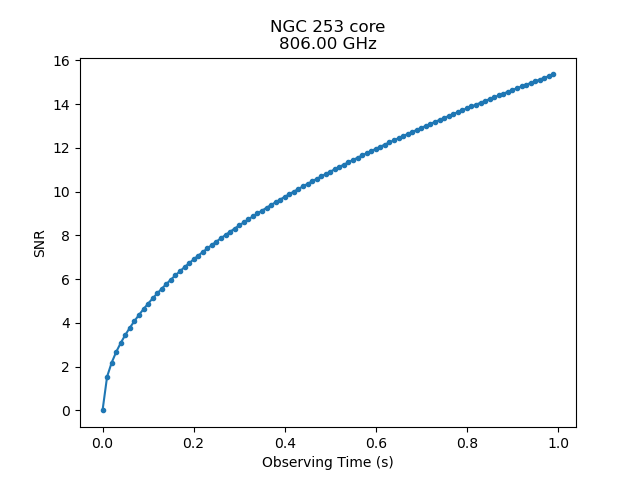

In [19]:
t_obs = np.arange(1e-9, 1, 0.01) * u.s

# flux density seen in the corresponding TIM channel due to this line
idx = np.argmin(abs(CO12_76 - nus_lw))
Snu_tim = (S / dnu_lw[idx]).to(u.Jy)
print(Snu_tim)

fig, ax = plt.subplots()
snrs = []
for t in t_obs:
    snrs.append(Snu_tim / (nei_lw[idx] * omegas_lw_tim[idx] / np.sqrt(t)))
ax.plot(t_obs, snrs, marker='.')
ax.set_xlabel('Observing Time (s)')
ax.set_ylabel('SNR')
ax.set_title('NGC 253 core' + f'\n{fobs(CO12_76, z):.2f}')

K-corrections from Herschel maps in MJy/sr:

Read off MJy/sr from 350 um filter, which is near-ish to the middle of our full band coverage in LW array.

For cold galactic dust clouds like RCW 36, assume a ~50 K dust temperature-dominated spectrum:
https://ui.adsabs.harvard.edu/abs/1994A&A...284..936V, Table 2

What is the power law approximation in the RJ part of the curve we observe?

$I(\nu) = I(\nu_0) (\nu / \nu_0)^{-\alpha}$

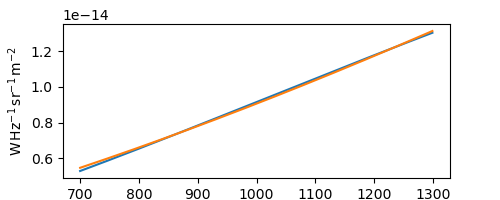

In [20]:
def Bn(nu, T):
    a = 2 * c.h * nu**3 / c.c**2
    b = 1 / (np.exp((c.h * nu) / (c.k_B * T)) - 1)
    return (a * b).to(u.W / u.m**2 / u.Hz) / u.sr


def Bl(lambd, T):
    a = 2 * c.h * c.c**2 / lambd**5
    b = 1 / (np.exp((c.h * c.c) / (lambd * c.k_B * T)) - 1)
    return (a * b).to(u.W / u.m**2 / u.um) / u.sr

def In(nu, I0, nu0, alpha):
    return I0 * (nu / nu0) ** alpha


nus = np.arange(700, 1300) * u.GHz
b = Bn(nus, 50 * u.K)

nu0 = ((c.c) / (350*u.um)).to(u.GHz)
idx_nu0 = np.argmin(np.abs(nus - nu0))

alpha = 1.42

plt.figure(figsize=(5,2));
plt.plot(nus, b)
plt.plot(nus, In(nus, b[idx_nu0], nu0, alpha))

So this dust spectrum has a spectral index ~+1.4, in contrast to the assumed Herschel power law spectral index of -1 that is used by default when making maps from pipeline products.

We can read off (or calculate, if we want to download Herschel pipeline data) the K-correction factor from the SPIRE instrument guide:
https://www.cosmos.esa.int/documents/12133/1035800/The+Herschel+Explanatory+Supplement%2C%20Volume+IV+-+THE+SPECTRAL+AND+PHOTOMETRIC+IMAGING+RECEIVER+%28SPIRE%29/c36d074d-32b4-48ec-b13f-4ca320788df3

From Fig. 5.4, we can see that for the 350 um band, an index of ~1.4 is a correction that is still quite close to 1, different by probably <1%. So we'll neglect it when doing estimates from 350 um maps. It's worth noting that the 500 um band correction at this index is higher, a few %. See also Fig. 5.5, which does this for modified blackbodies of given temperatures.

This approximation is confirmed in Table 5.7, so for the purposes of choosing bright first-light source fields we can convert map-space specific intensities in areas that are spatially even across a TIM beam to fluxes at the map wavelength by multiplying by the TIM beam size.

In [21]:
nu_idx = np.argmin(abs(nus_lw - nu0))
dnu_map = dnu_lw[nu_idx]

# how wrong is the approximation that the flux is constant across a channel?
I_center = In(nu0, Bn(nu0, 50 * u.K), nu0, alpha)
I_left = In(nu0 - dnu_map/2, Bn(nu0 - dnu_map/2, 50 * u.K), nu0 - dnu_map/2, alpha)
I_right = In(nu0 + dnu_map/2, Bn(nu0 + dnu_map/2, 50 * u.K), nu0 + dnu_map/2, alpha)
I_center, I_left, I_right
(I_right - I_left) / I_center

<Quantity 0.00562577>

Pretty good assumption, less than 1% for this dust model. We will assume that the specific intensity of the map is constant across a channel. We can directly calculate SNR in Jy:

Based on the Herschel maps, what SNR might we expect in the detector channel corresponding to the map?

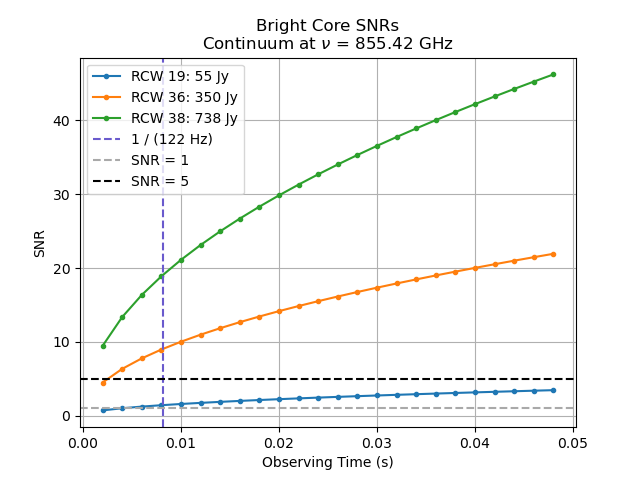

In [ ]:
# c.f. https://docs.google.com/presentation/d/1otKZh0_TYD8JynKNAEOLQqRT5zVajmM3J5ZA2BhLr7g/edit?slide=id.g38d10119fe7_0_59#slide=id.g38d10119fe7_0_59
# average specific intensity in pixels of a TIM beam FWHM-sized circular area
# pulled from a bright spot in a Herschel 350 um map of each source.
flux_densities = {
    'RCW 19': 55 * u.Jy, # RCW 19 bright core
    'RCW 36': 350 * u.Jy, # RCW 36 bright core
    'RCW 38': 738 * u.Jy, # RCW 38 bright core
}

dt = 0.002
t_obs = np.arange(dt, .05, dt) * u.s

fig, ax = plt.subplots()
for obj, flux_dens in flux_densities.items():
    snrs = []
    for t in t_obs:
        snrs.append(flux_dens / (nei_lw[nu_idx] * omegas_lw_tim[nu_idx] / np.sqrt(t)))
    ax.plot(t_obs, snrs, marker='.', label=obj + f': {flux_dens:.0f}')
ax.axvline(1/122 * u.s, linestyle='--', color='slateblue', label='1 / (122 Hz)')
ax.axhline(1, linestyle='--', color='darkgrey', label='SNR = 1')
ax.axhline(5, linestyle='--', color='k', label='SNR = 5')
ax.legend()
ax.set_xlabel('Observing Time (s)')
ax.set_ylabel('SNR')
ax.set_title('Bright Core SNRs' + f'\nContinuum at $\\nu$ = {nus_lw[nu_idx].to(u.GHz):.2f}')
ax.grid()